In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Train (1).csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


### Imputing Missing Values

In [ ]:
# Impute 'Item_Weight' with the mean
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

# Impute 'Outlet_Size' with the mode
mode_outlet_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'].fillna(mode_outlet_size, inplace=True)

# Verify that null values are handled
print('Missing values after imputation:')
display(df.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_648/1014889408.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_648/1014889408.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


### Handling Zero Values in Item_Visibility

In [ ]:
# Replace 0 in 'Item_Visibility' with NaN first to treat them as missing
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

# Impute missing 'Item_Visibility' values with the mean visibility for each 'Item_Type'
df['Item_Visibility'] = df.groupby('Item_Type')['Item_Visibility'].transform(lambda x: x.fillna(x.mean()))

# Verify that there are no more zeros or NaN values in Item_Visibility
print('Number of zeros in Item_Visibility after imputation:', (df['Item_Visibility'] == 0).sum())
print('Missing values after Item_Visibility imputation:')
display(df.isnull().sum())

Number of zeros in Item_Visibility after imputation: 0
Missing values after Item_Visibility imputation:


,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


### Create Outlet_Age Feature

In [ ]:
# Calculate the current year (assuming data is for 2018 based on common Big Mart Sales datasets)
current_year = 2018

# Create 'Outlet_Age' feature
df['Outlet_Age'] = current_year - df['Outlet_Establishment_Year']

# Display the first few rows with the new feature and check its descriptive statistics
print('DataFrame with new "Outlet_Age" feature:')
display(df[['Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Age']].head())
print('\nDescriptive statistics for Outlet_Age:')
display(df['Outlet_Age'].describe())

DataFrame with new "Outlet_Age" feature:


,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Age
0,OUT049,1999,19
1,OUT018,2009,9
2,OUT049,1999,19
3,OUT010,1998,20
4,OUT013,1987,31



Descriptive statistics for Outlet_Age:


,Outlet_Age
count,8523.000000
mean,20.168133
std,8.371760
min,9.000000
25%,14.000000
50%,19.000000
75%,31.000000
max,33.000000


### Advanced Exploratory Data Analysis (EDA)

#### Distribution of Numerical Features

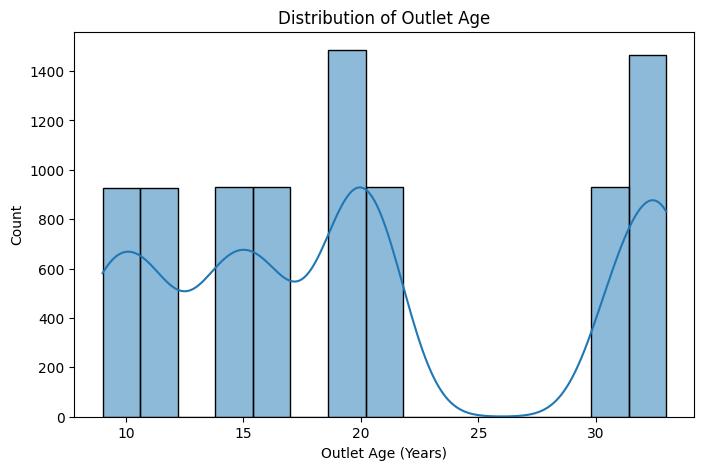

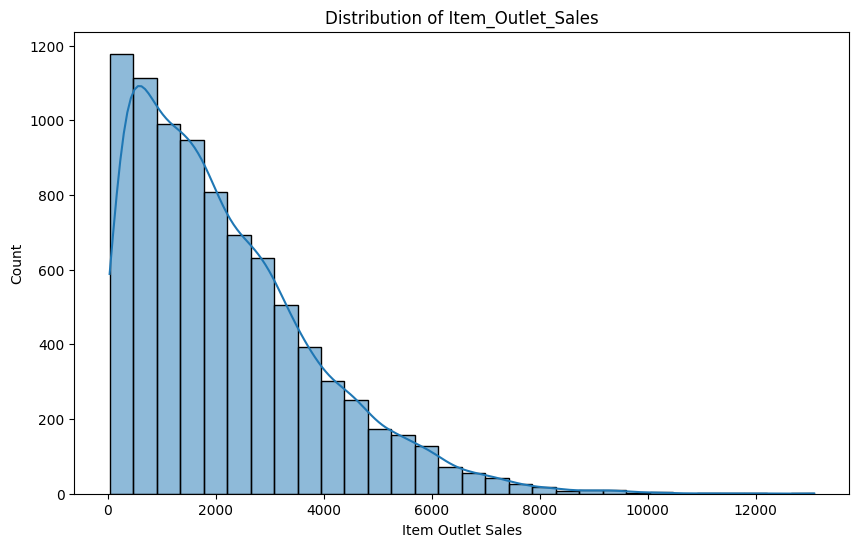

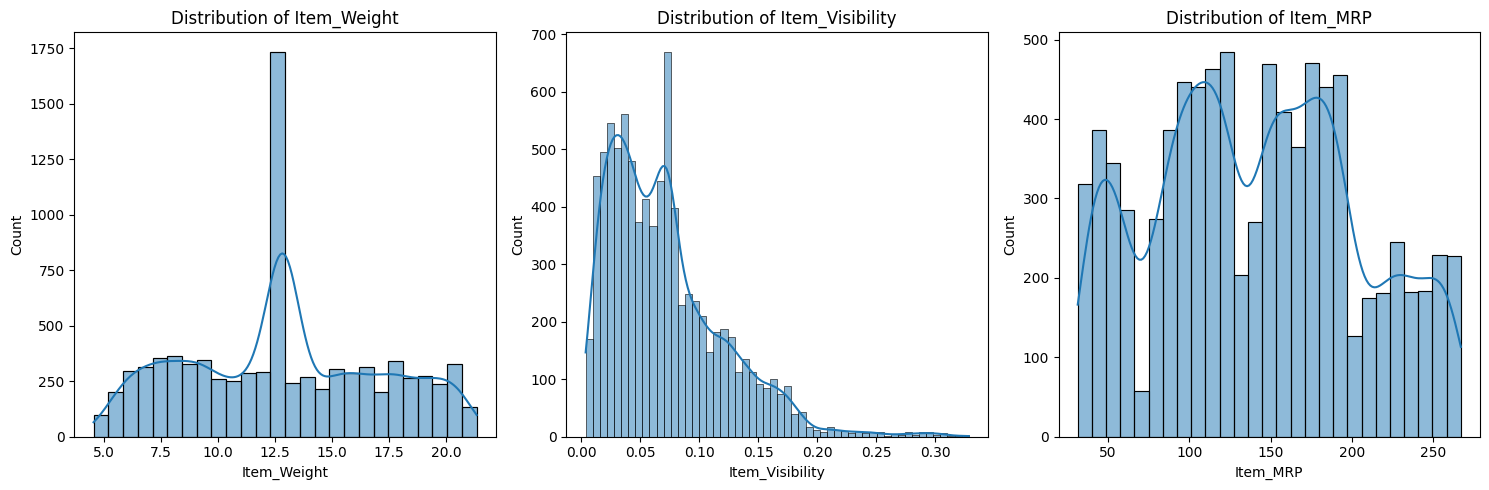

In [ ]:
# Visualize the distribution of Outlet_Age
plt.figure(figsize=(8, 5))
sns.histplot(df['Outlet_Age'], kde=True)
plt.title('Distribution of Outlet Age')
plt.xlabel('Outlet Age (Years)')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of Item_Outlet_Sales (target variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['Item_Outlet_Sales'], kde=True, bins=30)
plt.title('Distribution of Item_Outlet_Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of other numerical features
numerical_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Relationship with Target Variable (Item_Outlet_Sales)

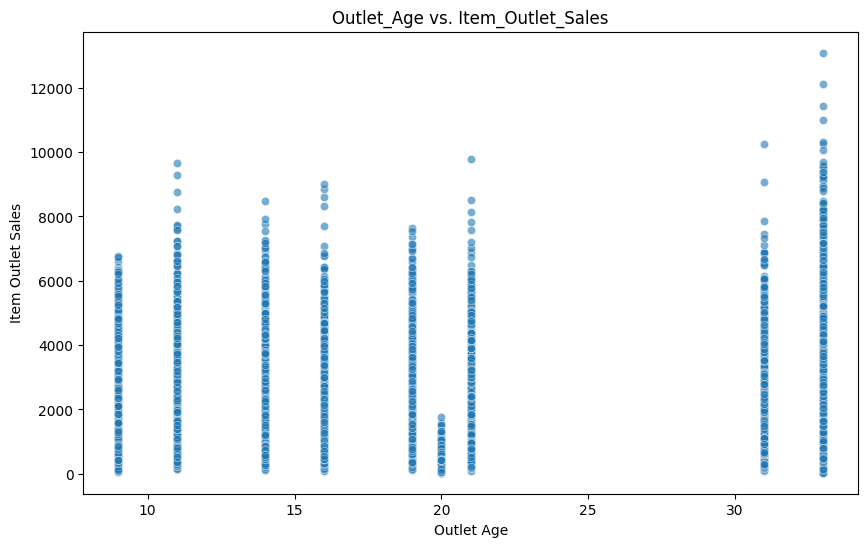

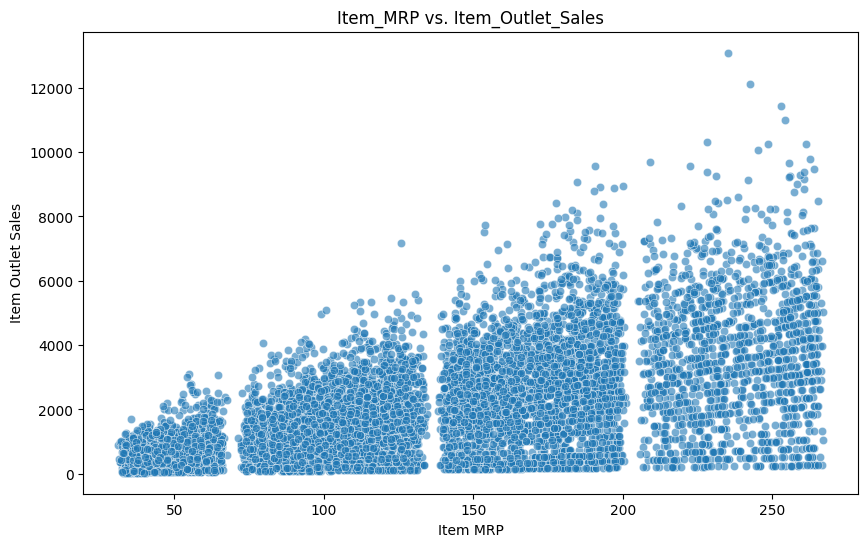

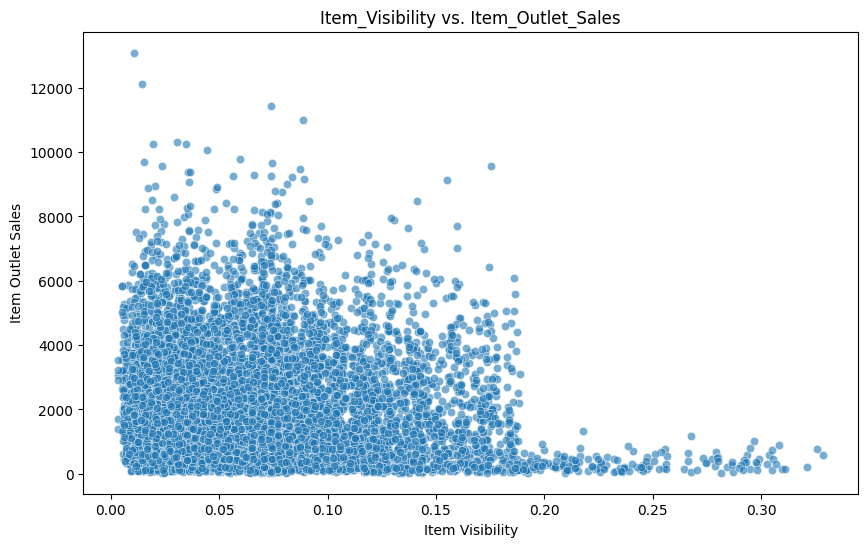

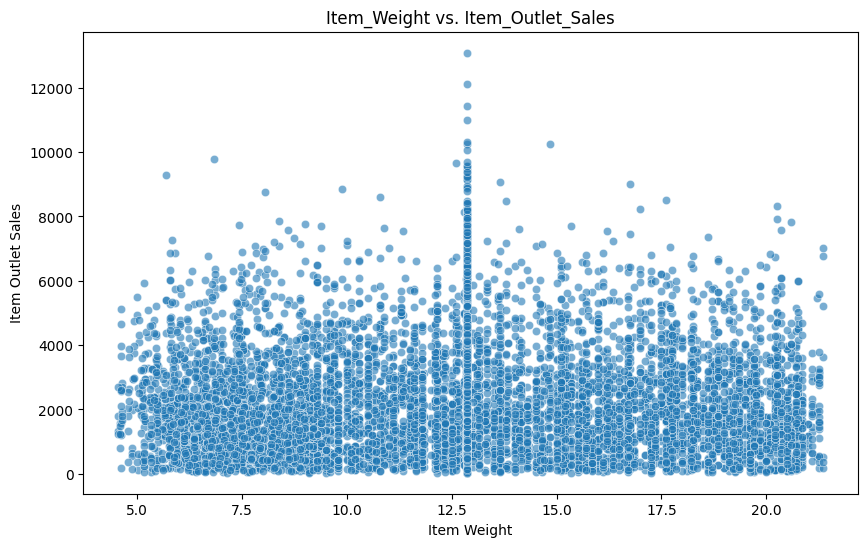

In [ ]:
# Relationship between Outlet_Age and Item_Outlet_Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Outlet_Age', y='Item_Outlet_Sales', data=df, alpha=0.6)
plt.title('Outlet_Age vs. Item_Outlet_Sales')
plt.xlabel('Outlet Age')
plt.ylabel('Item Outlet Sales')
plt.show()

# Relationship between Item_MRP and Item_Outlet_Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.6)
plt.title('Item_MRP vs. Item_Outlet_Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.show()

# Relationship between Item_Visibility and Item_Outlet_Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, alpha=0.6)
plt.title('Item_Visibility vs. Item_Outlet_Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Item Outlet Sales')
plt.show()

# Relationship between Item_Weight and Item_Outlet_Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_Weight', y='Item_Outlet_Sales', data=df, alpha=0.6)
plt.title('Item_Weight vs. Item_Outlet_Sales')
plt.xlabel('Item Weight')
plt.ylabel('Item Outlet Sales')
plt.show()


### Preprocessing Categorical Features

In [ ]:
# Standardize 'Item_Fat_Content'
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})

# Label Encoding for 'Outlet_Size' and 'Outlet_Location_Type' (ordinal features)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Outlet_Size'] = le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = le.fit_transform(df['Outlet_Location_Type'])

# One-Hot Encoding for nominal categorical features
# Identify remaining nominal categorical columns
nominal_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Drop 'Item_Identifier' and 'Outlet_Establishment_Year' (as 'Outlet_Age' is created)
df.drop(['Item_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)

print('DataFrame after categorical encoding and feature drops:')
display(df.head())
print('\nDataFrame Info after encoding:')
df.info()

DataFrame after categorical encoding and feature drops:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1,0,3735.1380,19,False,False,False,...,False,False,False,False,False,False,True,True,False,False
1,5.92,0.019278,48.2692,1,2,443.4228,9,True,False,False,...,True,False,False,False,False,False,False,False,True,False
2,17.50,0.016760,141.6180,1,0,2097.2700,19,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,19.20,0.073719,182.0950,1,2,732.3800,20,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.93,0.064963,53.8614,0,2,994.7052,31,False,False,False,...,False,False,False,False,False,False,False,True,False,False



DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Visibility                  8523 non-null   float64
 2   Item_MRP                         8523 non-null   float64
 3   Outlet_Size                      8523 non-null   int64  
 4   Outlet_Location_Type             8523 non-null   int64  
 5   Item_Outlet_Sales                8523 non-null   float64
 6   Outlet_Age                       8523 non-null   int64  
 7   Item_Fat_Content_Regular         8523 non-null   bool   
 8   Item_Type_Breads                 8523 non-null   bool   
 9   Item_Type_Breakfast              8523 non-null   bool   
 10  Item_Type_Canned                 8523 non-null   bool   
 11  Item_Type_Dairy                  8523 non-null   b

### Split Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

# Split the data into training and testing sets
# Using a common split of 80% for training and 20% for testing, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6818, 34)
Shape of X_test: (1705, 34)
Shape of y_train: (6818,)
Shape of y_test: (1705,)


### Scale Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (excluding encoded boolean columns and target variable)
numerical_cols_for_scaling = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the training data
X_train[numerical_cols_for_scaling] = scaler.fit_transform(X_train[numerical_cols_for_scaling])

# Apply scaling to the test data using the *fitted* scaler
X_test[numerical_cols_for_scaling] = scaler.transform(X_test[numerical_cols_for_scaling])

print('First 5 rows of scaled X_train numerical features:')
display(X_train[numerical_cols_for_scaling].head())

print('\nFirst 5 rows of scaled X_test numerical features:')
display(X_test[numerical_cols_for_scaling].head())

First 5 rows of scaled X_train numerical features:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
549,-0.800211,-0.727472,0.470709,-0.136169
7757,1.211317,-0.474636,0.457877,-0.493521
764,1.116657,0.115832,-0.482625,0.102066
6867,-1.078275,-0.837958,-1.603553,-0.493521
2716,-0.007432,1.375265,0.218375,0.102066



First 5 rows of scaled X_test numerical features:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
7503,0.335711,-0.911032,-0.998908,1.293240
2957,-1.171752,0.013068,-1.586048,0.102066
7031,0.383041,-0.601596,-1.596652,-0.136169
1084,-0.005623,-0.530410,0.508453,1.531475
856,-0.635739,-1.196365,0.889079,-0.731756


### Encode Categorical Features

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Exclude 'Item_Identifier' and 'Outlet_Identifier' if they are not meant for encoding (often they are unique IDs)
# However, for now, let's list all identified categorical columns to review.
# We might decide to drop them later or use them differently.
print("Categorical columns identified:")
print(categorical_cols)

# Display unique values and their counts for each categorical column to decide on encoding strategy
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())


Categorical columns identified:
Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

Unique values in 'Item_Identifier':
Item_Identifier
FDW13    10
FDG33    10
NCF42     9
FDW26     9
FDX31     9
         ..
FDY43     1
FDO33     1
FDK57     1
FDQ60     1
FDN52     1
Name: count, Length: 1559, dtype: int64

Unique values in 'Item_Fat_Content':
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Unique values in 'Item_Type':
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others           

## Model Evaluation and Training

In [ ]:
# Import necessary libraries for models and metrics
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a dictionary of regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'SVR': SVR(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

# Prepare to store results
results = []

# Iterate over models, train, predict, and evaluate
for name, model in models.items():
    print(f"\n--- Training and evaluating {name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Calculate Adjusted R^2
    n = X_test.shape[0]  # Number of observations
    p = X_test.shape[1]  # Number of predictors
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # Store results
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R^2': r2,
        'Adjusted R^2': adj_r2
    })

    # Print metrics
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"Adjusted R^2 Score: {adj_r2:.4f}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results)
print("\n--- Model Evaluation Summary ---")
display(results_df.sort_values(by='R^2', ascending=False))


--- Training and evaluating Linear Regression ---
MSE: 1142752.5349
RMSE: 1068.9960
MAE: 791.4948
R^2 Score: 0.5796
Adjusted R^2 Score: 0.5710

--- Training and evaluating Ridge ---
MSE: 1142656.2934
RMSE: 1068.9510
MAE: 791.3957
R^2 Score: 0.5796
Adjusted R^2 Score: 0.5710

--- Training and evaluating Lasso ---
MSE: 1140826.0852
RMSE: 1068.0946
MAE: 790.5831
R^2 Score: 0.5803
Adjusted R^2 Score: 0.5717

--- Training and evaluating KNeighborsRegressor ---
MSE: 1347360.0379
RMSE: 1160.7584
MAE: 815.0520
R^2 Score: 0.5043
Adjusted R^2 Score: 0.4942

--- Training and evaluating SVR ---
MSE: 2487425.9806
RMSE: 1577.1576
MAE: 1183.0519
R^2 Score: 0.0848
Adjusted R^2 Score: 0.0662

--- Training and evaluating DecisionTreeRegressor ---
MSE: 2255181.5784
RMSE: 1501.7262
MAE: 1034.7274
R^2 Score: 0.1703
Adjusted R^2 Score: 0.1534

--- Training and evaluating RandomForestRegressor ---
MSE: 1187609.2765
RMSE: 1089.7749
MAE: 761.0145
R^2 Score: 0.5631
Adjusted R^2 Score: 0.5542

--- Training and 

,Model,MSE,RMSE,MAE,R^2,Adjusted R^2
7,GradientBoostingRegressor,1.069632e+06,1034.229972,731.178713,0.606459,0.598447
2,Lasso,1.140826e+06,1068.094605,790.583133,0.580265,0.571720
1,Ridge,1.142656e+06,1068.951025,791.395718,0.579592,0.571033
0,Linear Regression,1.142753e+06,1068.996041,791.494764,0.579557,0.570997
6,RandomForestRegressor,1.187609e+06,1089.774874,761.014512,0.563053,0.554157
3,KNeighborsRegressor,1.347360e+06,1160.758389,815.051976,0.504277,0.494185
5,DecisionTreeRegressor,2.255182e+06,1501.726200,1034.727395,0.170270,0.153377
4,SVR,2.487426e+06,1577.157564,1183.051949,0.084822,0.066190


That's a very insightful question! The R-squared scores indicate the proportion of variance in the dependent variable that can be predicted from the independent variables. While our preprocessing steps were standard and correctly applied, the relatively low R-squared scores (even for the best model at around 0.60) suggest that the relationship between your features and the Item_Outlet_Sales might be complex, or that additional feature engineering or target variable transformations could be beneficial. It's not necessarily a 'mistake' but rather an indication of the challenges inherent in the dataset's predictability.

### Hyperparameter Tuning for Top Models

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- GradientBoostingRegressor Tuning ---
print("\n--- Tuning GradientBoostingRegressor ---")
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}
gb_model = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb_model, param_grid_gb, cv=3, scoring='r2', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print(f"Best parameters for GradientBoostingRegressor: {gb_grid.best_params_}")
print(f"Best R^2 score for GradientBoostingRegressor: {gb_grid.best_score_:.4f}")

y_pred_gb = gb_grid.best_estimator_.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
n_gb = X_test.shape[0]
p_gb = X_test.shape[1]
adj_r2_gb = 1 - (1 - r2_gb) * (n_gb - 1) / (n_gb - p_gb - 1)

print(f"Tuned GradientBoostingRegressor - MSE: {mse_gb:.4f}, RMSE: {rmse_gb:.4f}, MAE: {mae_gb:.4f}, R^2: {r2_gb:.4f}, Adjusted R^2: {adj_r2_gb:.4f}")

# --- Lasso Tuning ---
print("\n--- Tuning Lasso ---")
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}
lasso_model = Lasso(random_state=42)
lasso_grid = GridSearchCV(lasso_model, param_grid_lasso, cv=3, scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X_train, y_train)

print(f"Best parameters for Lasso: {lasso_grid.best_params_}")
print(f"Best R^2 score for Lasso: {lasso_grid.best_score_:.4f}")

y_pred_lasso = lasso_grid.best_estimator_.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
n_lasso = X_test.shape[0]
p_lasso = X_test.shape[1]
adj_r2_lasso = 1 - (1 - r2_lasso) * (n_lasso - 1) / (n_lasso - p_lasso - 1)

print(f"Tuned Lasso - MSE: {mse_lasso:.4f}, RMSE: {rmse_lasso:.4f}, MAE: {mae_lasso:.4f}, R^2: {r2_lasso:.4f}, Adjusted R^2: {adj_r2_lasso:.4f}")

# --- RandomForestRegressor Tuning ---
print("\n--- Tuning RandomForestRegressor ---")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 4]
}
rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_model, param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters for RandomForestRegressor: {rf_grid.best_params_}")
print(f"Best R^2 score for RandomForestRegressor: {rf_grid.best_score_:.4f}")

y_pred_rf = rf_grid.best_estimator_.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
n_rf = X_test.shape[0]
p_rf = X_test.shape[1]
adj_r2_rf = 1 - (1 - r2_rf) * (n_rf - 1) / (n_rf - p_rf - 1)

print(f"Tuned RandomForestRegressor - MSE: {mse_rf:.4f}, RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R^2: {r2_rf:.4f}, Adjusted R^2: {adj_r2_rf:.4f}")


--- Tuning GradientBoostingRegressor ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for GradientBoostingRegressor: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best R^2 score for GradientBoostingRegressor: 0.5892
Tuned GradientBoostingRegressor - MSE: 1072265.5738, RMSE: 1035.5026, MAE: 730.4704, R^2: 0.6055, Adjusted R^2: 0.5975

--- Tuning Lasso ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters for Lasso: {'alpha': 1}
Best R^2 score for Lasso: 0.5534
Tuned Lasso - MSE: 1140826.0852, RMSE: 1068.0946, MAE: 790.5831, R^2: 0.5803, Adjusted R^2: 0.5717

--- Tuning RandomForestRegressor ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for RandomForestRegressor: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}
Best R^2 score for RandomForestRegressor: 0.5940
Tuned RandomForestRegressor - MSE: 1047865.7554, RMSE: 1023.6531, MAE: 716.8759, R^2: 0.6145, Adjusted R^2: 0.6